In [1]:
from analytical import *
from electronic import *
from engine import *
from integrator import *
from selector import *
from trajectory import *
import numpy as np
import matplotlib.pyplot as plt

In [53]:
# DEFINE ANALYTICAL SYSTEM

v_init = -0.0087
q_init = 1.0
coeff_init = np.array([1.0, 0.0], dtype=complex)
mass = 1836.15
act_state_init = 0
dt = 5
max_steps = 10000000

SHO_H = DoubleHarmonic(k=0.1, x0=1.0, vc=0.01)

In [54]:
# DEFINE STABLE REGIONS

bound_A=-0.8
bound_B=0.8

def in_stateA(q, s):
    return q<bound_A and s == 0

def in_stateB(q, s):
    return q>bound_B and s == 0

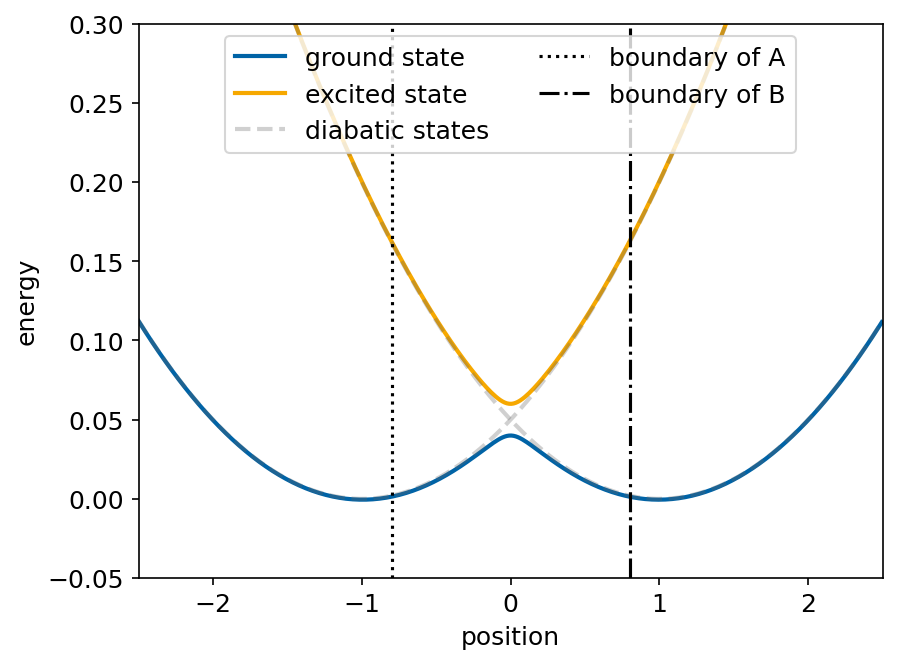

In [55]:
# PLOT ANALYTICAL SYSTEM

adiabatic = []
diabatic = []
for s in np.arange(2):
    adiabatic.append([])
    diabatic.append([])
pos = np.arange(-2.5,2.5,0.015)
for i in range(len(pos)):  
    E_states=np.linalg.eigh(SHO_H.H(pos[i])) #states have to be in right order (value at position ascending)
    E_diag = np.diag(SHO_H.H(pos[i]))
    for st in range(2):
        adiabatic[st].append(E_states[st])
        diabatic[st].append(E_diag[st])

plt.figure(dpi=150)
plt.rcParams.update({'font.size': 12})
labelstates = ["ground state", "excited state"]
colorstates = ["#0063A6","#F6A800","#666666"]
for s in range(2):
    plt.plot(pos,np.array(adiabatic[0])[:,s], label=labelstates[s],color=colorstates[s],linewidth=2.0)
plt.plot(pos,np.array(diabatic[0]), "--", label="diabatic states",color=colorstates[2],alpha=0.3,linewidth=2.0)
plt.plot(pos,np.array(diabatic[1]), "--", color=colorstates[2],alpha=0.3,linewidth=2.0)
plt.axvline(x=bound_A, linestyle=":", label="boundary of A", color='black')
plt.axvline(x=bound_B, linestyle="-.", label="boundary of B", color='black')
plt.ylim(-0.05,.3)
plt.xlim(-2.5,2.5)
plt.xlabel("position")
plt.ylabel("energy")
plt.legend(ncol=2, loc=9,fontsize=12)
plt.show()

In [56]:
# RUN SEED TRAJECTORY

C_init = SHO_H.eigvecs(q_init)

initial_snapshot = Snapshot(positions=q_init,
                            velocities=v_init,
                            coefficients=coeff_init,
                            active_state=act_state_init,
                            gauge=C_init,
                            mass=mass,
                            is_grid=True)

seedMASH = MASHEngine(model=SHO_H, dt=dt, initial_snapshot=initial_snapshot)

seed_traj = seedMASH.propagate_until_X(max_steps=max_steps, stateA=in_stateA, stateB=in_stateB)

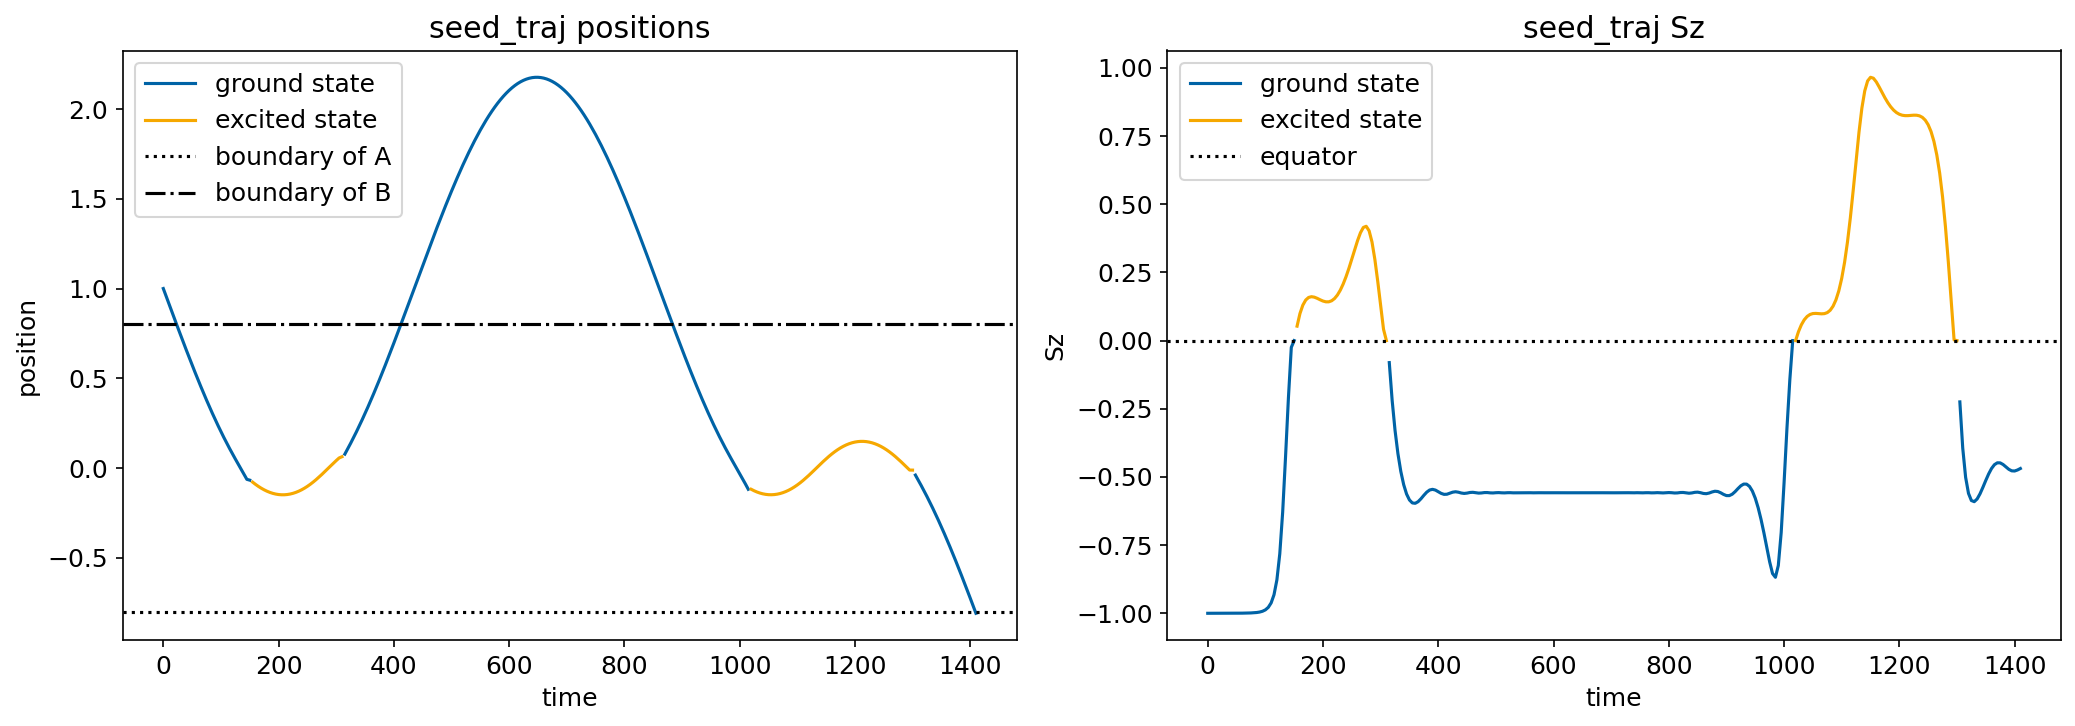

In [57]:
# PLOT SEED TRAJECTORY

# --- Positions ---
oscillator_positions = np.array([seed_traj[i].positions for i in range(len(seed_traj))])
active_states = np.array([seed_traj[i].active_state for i in range(len(seed_traj))])
ground_state_positions = np.copy(oscillator_positions)
ground_state_positions[active_states > 0] = np.nan
excited_state_positions = np.copy(oscillator_positions)
excited_state_positions[active_states != 1] = np.nan

# --- Coefficients ---
oscillator_coeffs = np.array([sz_from_coeff(seed_traj[i].coefficients) for i in range(len(seed_traj))])
ground_state_coeffs = np.copy(oscillator_coeffs)
ground_state_coeffs[active_states > 0] = np.nan
excited_state_coeffs = np.copy(oscillator_coeffs)
excited_state_coeffs[active_states != 1] = np.nan

# --- Create subplots ---
fig, axes = plt.subplots(ncols=2, figsize=(14, 5), dpi=150)

# Left: Positions
axes[0].plot(np.arange(len(seed_traj)) * dt, ground_state_positions, color=colorstates[0], label="ground state")
axes[0].plot(np.arange(len(seed_traj)) * dt, excited_state_positions, color=colorstates[1], label="excited state")
axes[0].axhline(y=bound_A, linestyle=":", color='black', label="boundary of A")
axes[0].axhline(y=bound_B, linestyle="-.", color='black', label="boundary of B")
axes[0].set_xlabel("time")
axes[0].set_ylabel("position")
axes[0].set_title("seed_traj positions")
axes[0].legend(loc=2)

# Right: Sz
axes[1].plot(np.arange(len(seed_traj)) * dt, ground_state_coeffs, color=colorstates[0], label="ground state")
axes[1].plot(np.arange(len(seed_traj)) * dt, excited_state_coeffs, color=colorstates[1], label="excited state")
axes[1].axhline(y=0, linestyle=":", color='black', label="equator")
axes[1].set_xlabel("time")
axes[1].set_ylabel("Sz")
axes[1].set_title("seed_traj Sz")
axes[1].legend(loc=2)

plt.tight_layout()
plt.show()

In [20]:
selector = UniformShootingSelector(temp=300, mass=mass, alpha=0.9)
current_traj = seed_traj
tps_ensemble = [current_traj]

n_tps_iterations = 1000
max_traj_length = 2000

pad_L = 1
pad_R = 1

accept = 0
reject = 0

for i in range(n_tps_iterations):
    print(f"--- TPS Iteration {i} ---")
    shooting_snap, l_old = selector.select_and_perturb(current_traj, pad_L=pad_L, pad_R=pad_R)
    engine_fwd = MASHEngine(model=SHO_H, dt=dt, initial_snapshot=shooting_snap)
    traj_fwd = engine_fwd.propagate_until_basin(max_traj_length, in_stateA, in_stateB)

    shooting_snap_rev = shooting_snap.reversed()
    engine_bwd = MASHEngine(model=SHO_H, dt=dt, initial_snapshot=shooting_snap_rev)
    traj_bwd_raw = engine_bwd.propagate_until_basin(max_traj_length, in_stateA, in_stateB)
    traj_bwd_fixed = [snap.reversed() for snap in reversed(traj_bwd_raw)]

    stitched_states = traj_bwd_fixed[:-1] + list(traj_fwd)
    trial_traj = Trajectory(stitched_states)

    start_q = trial_traj[0].positions
    end_q = trial_traj[-1].positions

    start_s = trial_traj[0].active_state
    end_s = trial_traj[-1].active_state

    connected = False
    if in_stateA(start_q, start_s) and in_stateB(end_q, end_s): connected = True
    if in_stateB(start_q, start_s) and in_stateA(end_q, end_s): connected = True

    L_new_grid = sum(1 for snap in trial_traj if snap.is_grid)
    l_new = L_new_grid - pad_L - pad_R

    if l_new > 0 and selector.check_acceptance(l_old, l_new, connected):
        current_traj = trial_traj
        print("ACCEPTED")
        accept += 1
    else:
        print("REJECTED")
        reject += 1
        
    
    tps_ensemble.append(current_traj)

print(f"TPS finished! Ensemble size: {len(tps_ensemble)}")
    

--- TPS Iteration 0 ---
Hop search finished after 29 iterations. Hop is located at x=0.32818918237332234.
Hop is allowed, at time 58
Hop search finished after 29 iterations. Hop is located at x=-0.3113089026192114.
Hop is allowed, at time 98
ACCEPTED
--- TPS Iteration 1 ---
Hop search finished after 26 iterations. Hop is located at x=-0.24844331749255621.
Hop is allowed, at time 35
Hop search finished after 28 iterations. Hop is located at x=0.24450148439524239.
Hop is allowed, at time 120
ACCEPTED
--- TPS Iteration 2 ---
Hop search finished after 28 iterations. Hop is located at x=0.0993226925191747.
Hop is allowed, at time 26
Hop search finished after 21 iterations. Hop is located at x=-0.7346770132661546.
Hop is allowed, at time 30
Hop search finished after 29 iterations. Hop is located at x=0.038232882825436604.
Hop is allowed, at time 103
Hop search finished after 26 iterations. Hop is located at x=0.04960019021290678.
Hop is allowed, at time 49
ACCEPTED
--- TPS Iteration 3 ---
Ho

In [8]:
# Question: How to get shooting points and acceptance from trajectory in tps_ensemble?

In [52]:
for k in range(10):
    traj = tps_ensemble[k+200]

    # --- Positions ---
    oscillator_positions = np.array([traj[i].positions for i in range(len(traj))])
    active_states = np.array([traj[i].active_state for i in range(len(traj))])
    ground_state_positions = np.copy(oscillator_positions)
    ground_state_positions[active_states > 0] = np.nan
    excited_state_positions = np.copy(oscillator_positions)
    excited_state_positions[active_states != 1] = np.nan

    # --- Coefficients ---
    oscillator_coeffs = np.array([sz_from_coeff(traj[i].coefficients) for i in range(len(traj))])
    ground_state_coeffs = np.copy(oscillator_coeffs)
    ground_state_coeffs[active_states > 0] = np.nan
    excited_state_coeffs = np.copy(oscillator_coeffs)
    excited_state_coeffs[active_states != 1] = np.nan

    # --- Create subplots ---
    fig, axes = plt.subplots(ncols=2, figsize=(14, 5), dpi=150)

    # Left: Positions
    axes[0].plot(np.arange(len(traj)) * dt, ground_state_positions, color=colorstates[0], label="ground state")
    axes[0].plot(np.arange(len(traj)) * dt, excited_state_positions, color=colorstates[1], label="excited state")
    axes[0].axhline(y=bound_A, linestyle=":", color='black', label="boundary of A")
    axes[0].axhline(y=bound_B, linestyle="-.", color='black', label="boundary of B")
    axes[0].set_xlabel("time")
    axes[0].set_ylabel("position")
    axes[0].set_title(f"traj{k:3d} positions")
    axes[0].legend(loc=2)

    # Right: Sz
    axes[1].plot(np.arange(len(traj)) * dt, ground_state_coeffs, color=colorstates[0], label="ground state")
    axes[1].plot(np.arange(len(traj)) * dt, excited_state_coeffs, color=colorstates[1], label="excited state")
    axes[1].axhline(y=0, linestyle=":", color='black', label="equator")
    axes[1].set_xlabel("time")
    axes[1].set_ylabel("Sz")
    axes[1].set_title(f"traj{k:3d} Sz")
    axes[1].legend(loc=2)

    plt.tight_layout()
    plt.show()

NameError: name 'tps_ensemble' is not defined

In [10]:
# CALCULATE ACCEPTANCE PROBABILITY

if n_tps_iterations!=accept+reject:
    print("check total number of trajectories")
acceptance_ratio = accept/(accept+reject)
print("acceptance ratio",acceptance_ratio*100, "%")

acceptance ratio 41.8 %


In [11]:
# Question: What is this is_grid/remove_off_grid thingi doing?

def remove_off_grid(traj):
    return Trajectory([snap for snap in traj if snap.is_grid])

production_ensemble = tps_ensemble[200:]
production_ensemble = [remove_off_grid(traj) for traj in production_ensemble]

#dt = 5
transit_times = [len(traj) * dt for traj in production_ensemble]
transit_times.pop(0)

mean_time = np.mean(transit_times)
std_time = np.std(transit_times)

print(f"Mean Transition Time: {mean_time:.2f} atomic units")
print(f"Standard Deviation: {std_time:.2f} atomic units")

Mean Transition Time: 559.81 atomic units
Standard Deviation: 85.88 atomic units


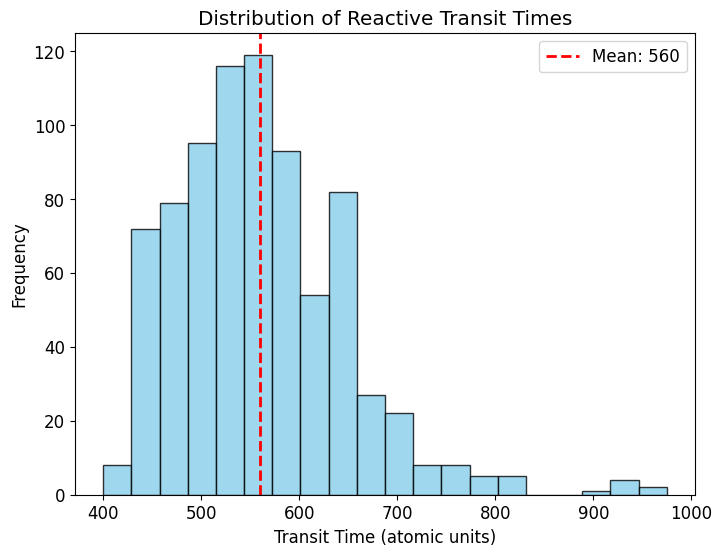

In [12]:
# PLOT DISTRIBUTION OF REACTIVE TRANSITION TIMES (Question again: only this is_grid trajectories?)

from matplotlib import pyplot as plt

plt.figure(figsize=(8, 6))
plt.hist(transit_times, bins=20, color='skyblue', edgecolor='black', alpha=0.8)
plt.title("Distribution of Reactive Transit Times")
plt.xlabel("Transit Time (atomic units)")
plt.ylabel("Frequency")
plt.axvline(mean_time, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_time:.0f}')
plt.legend()
plt.show()

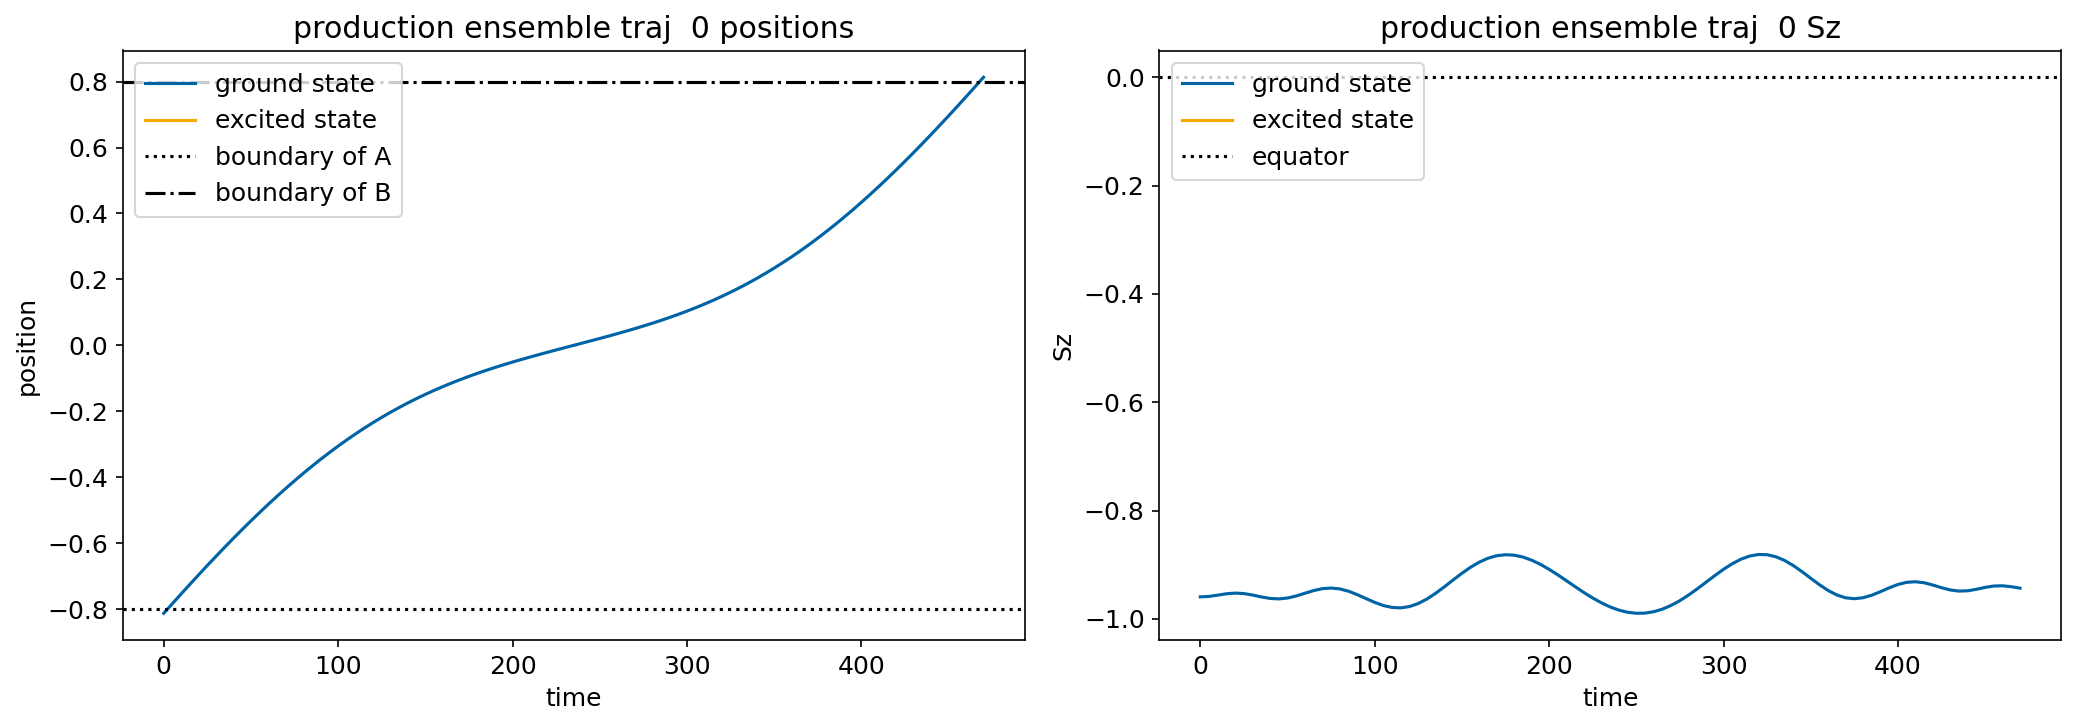

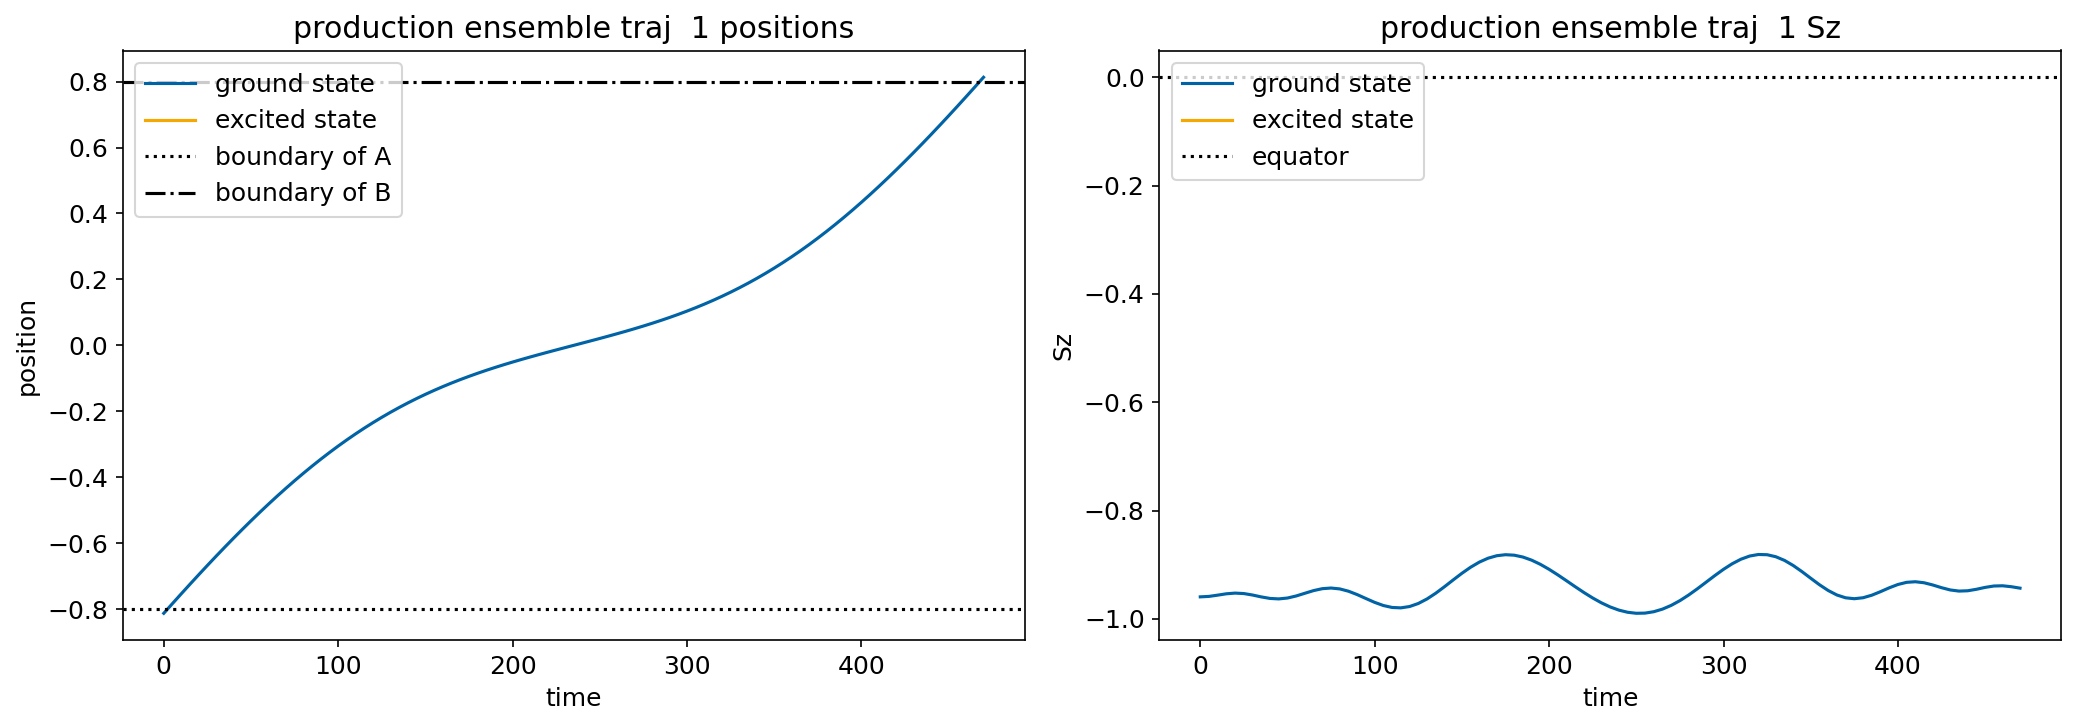

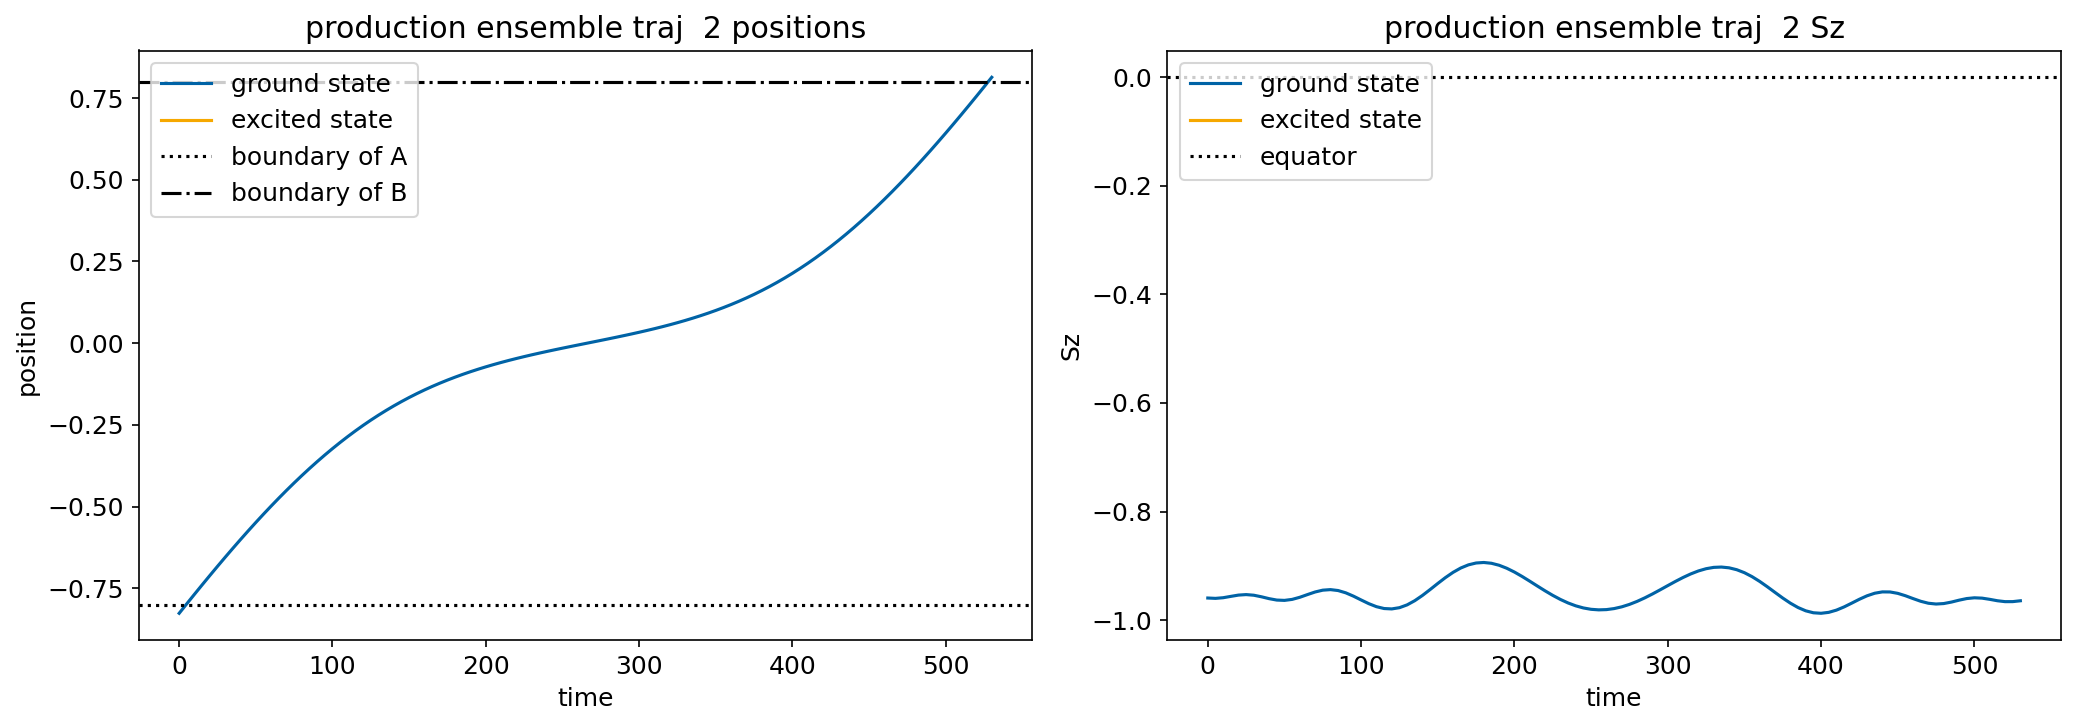

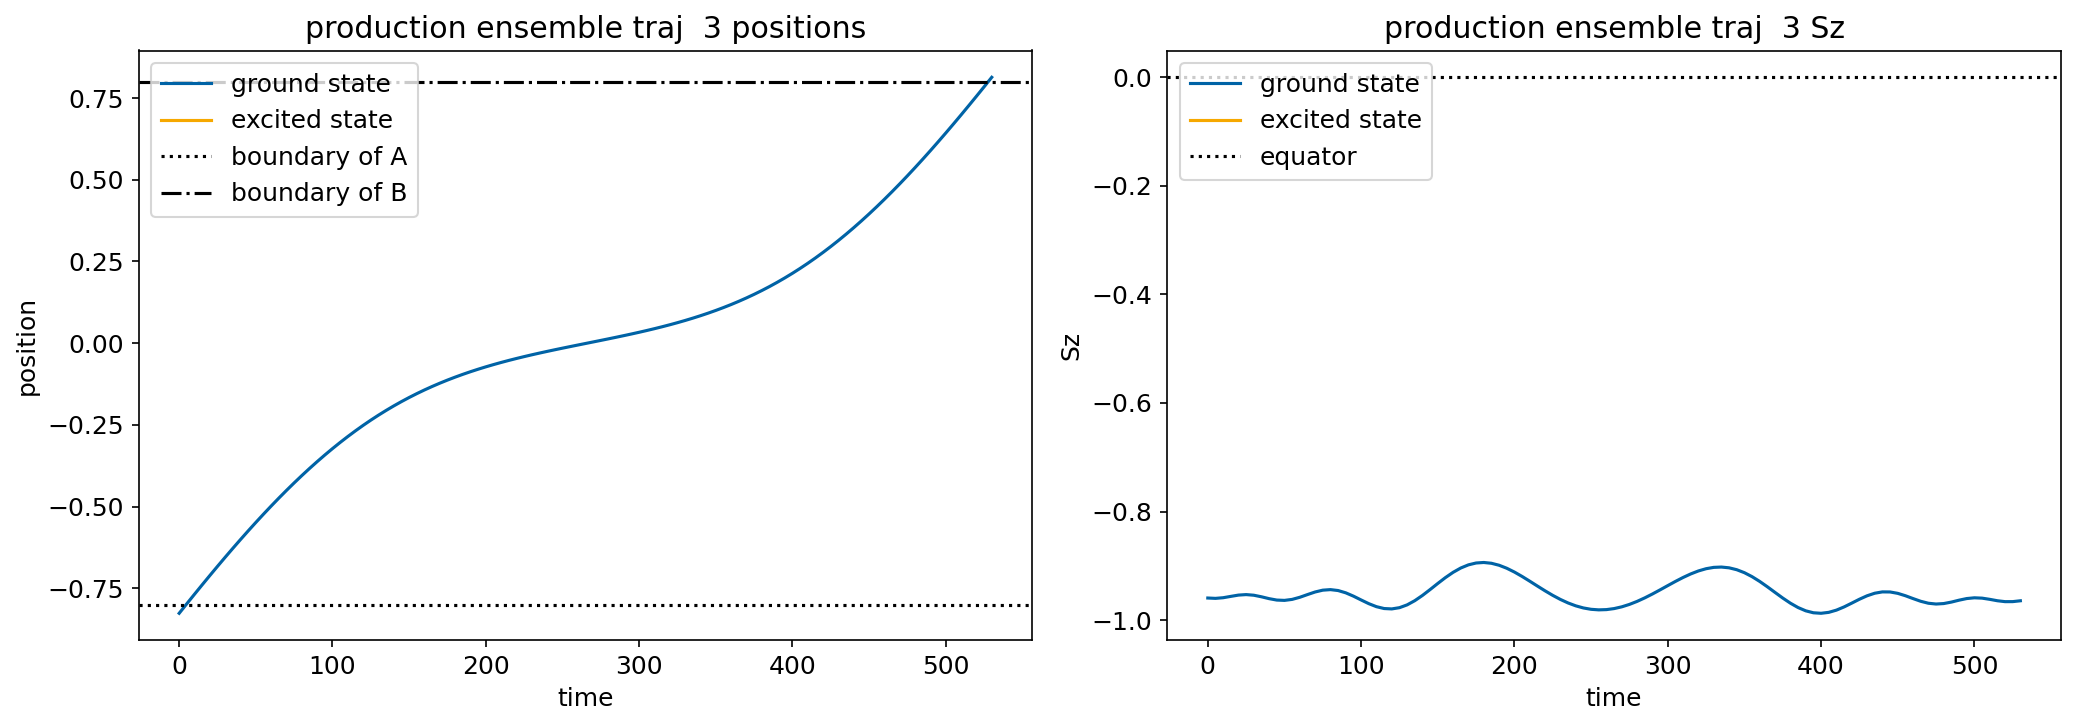

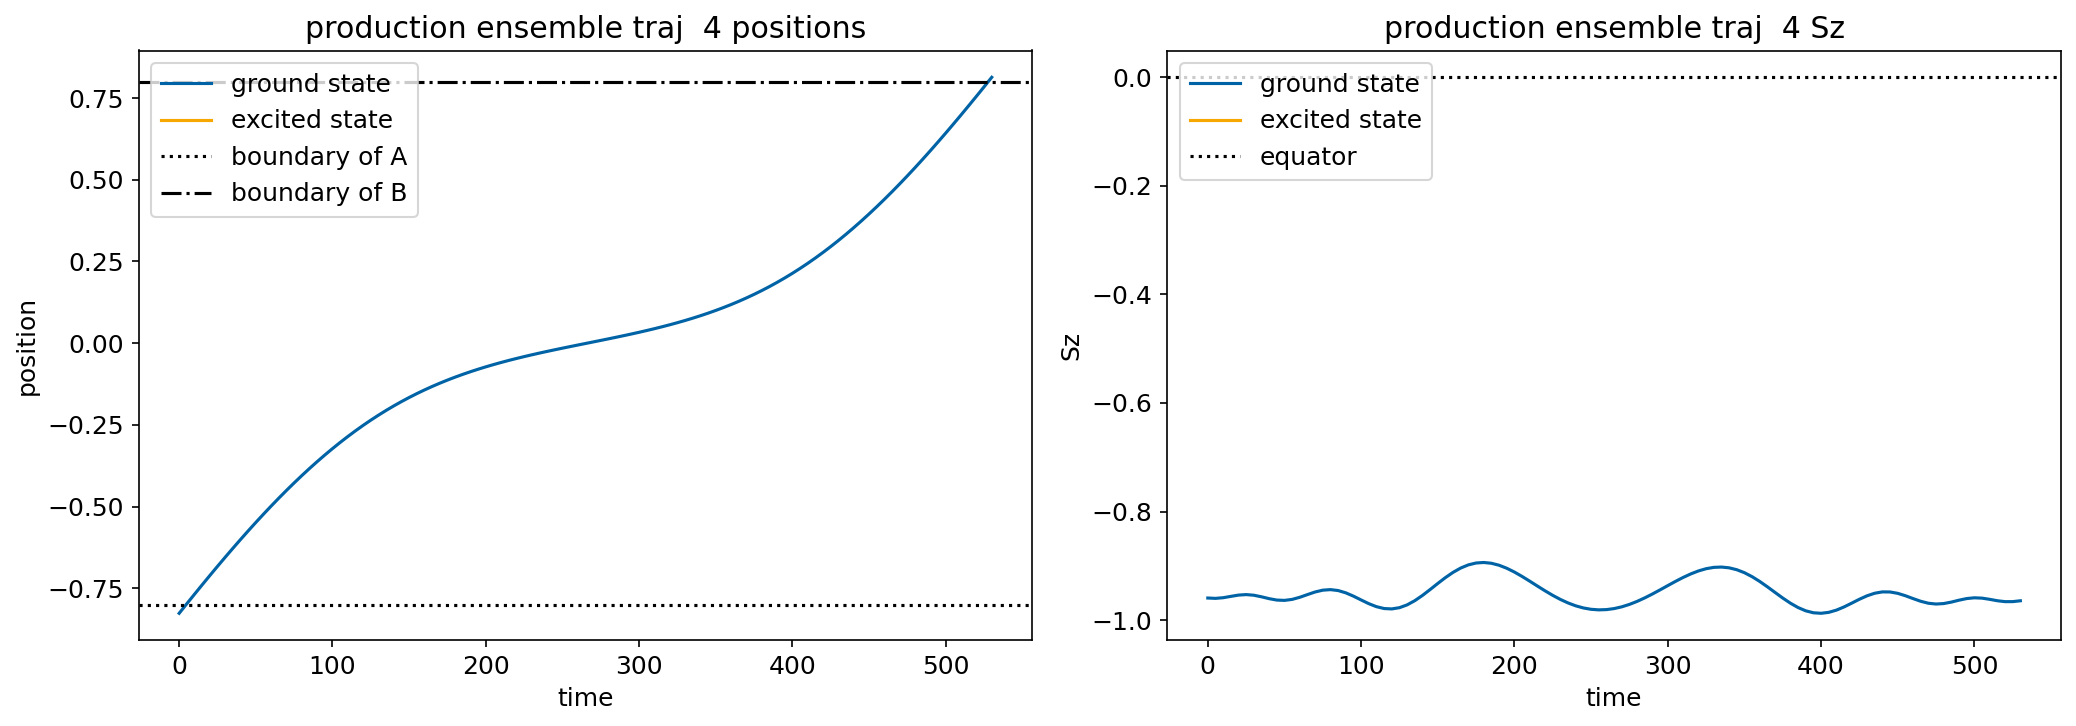

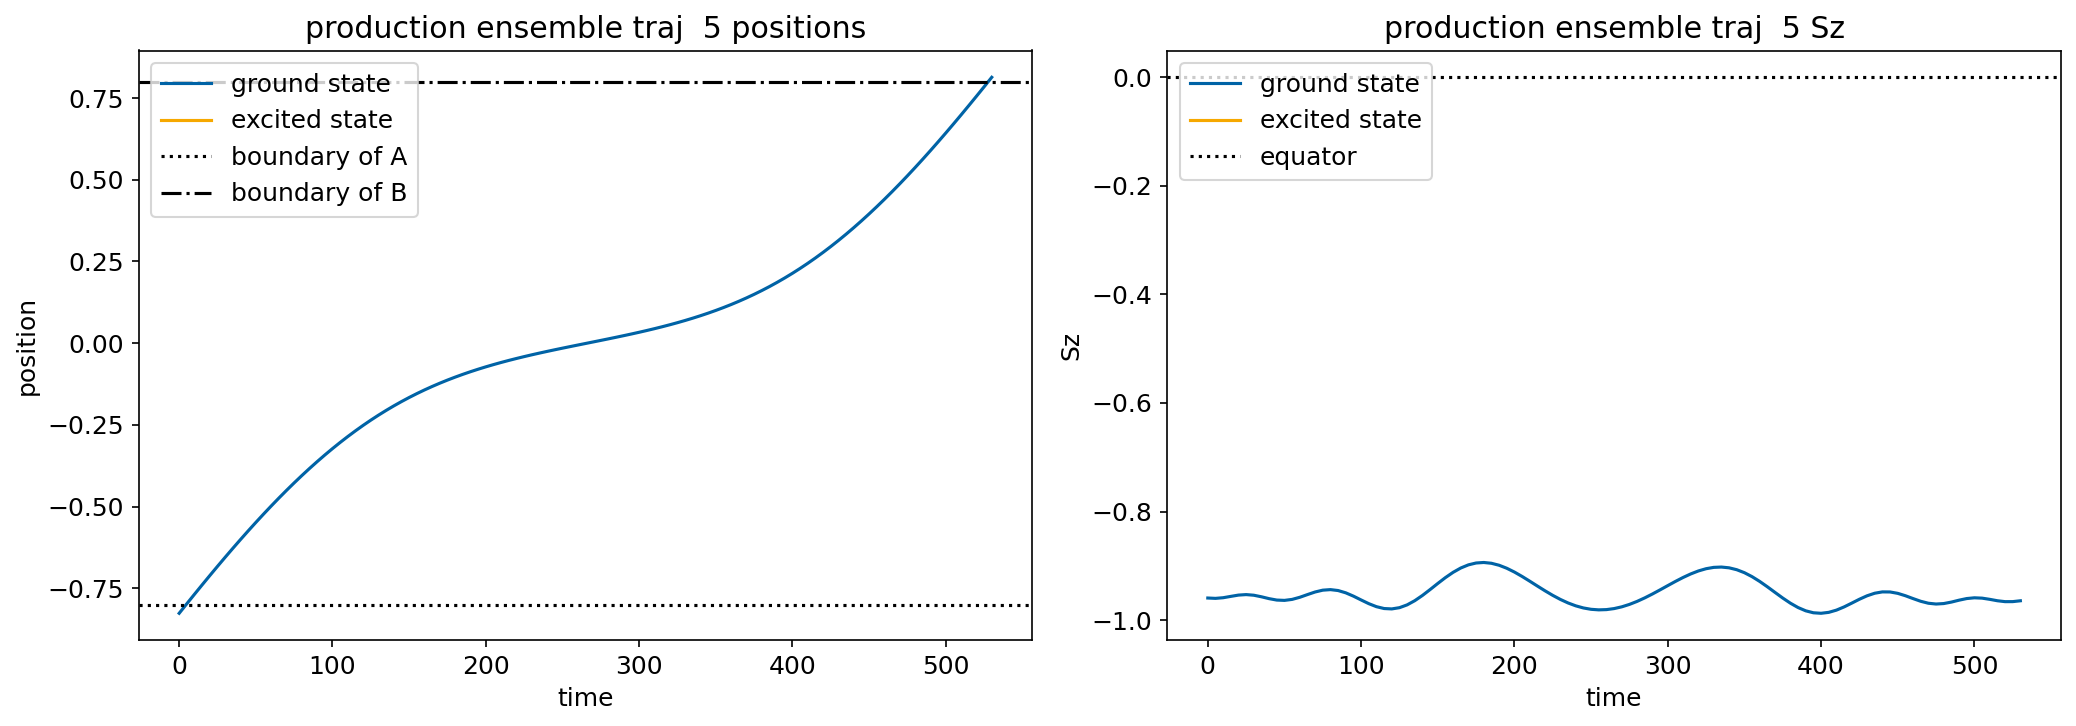

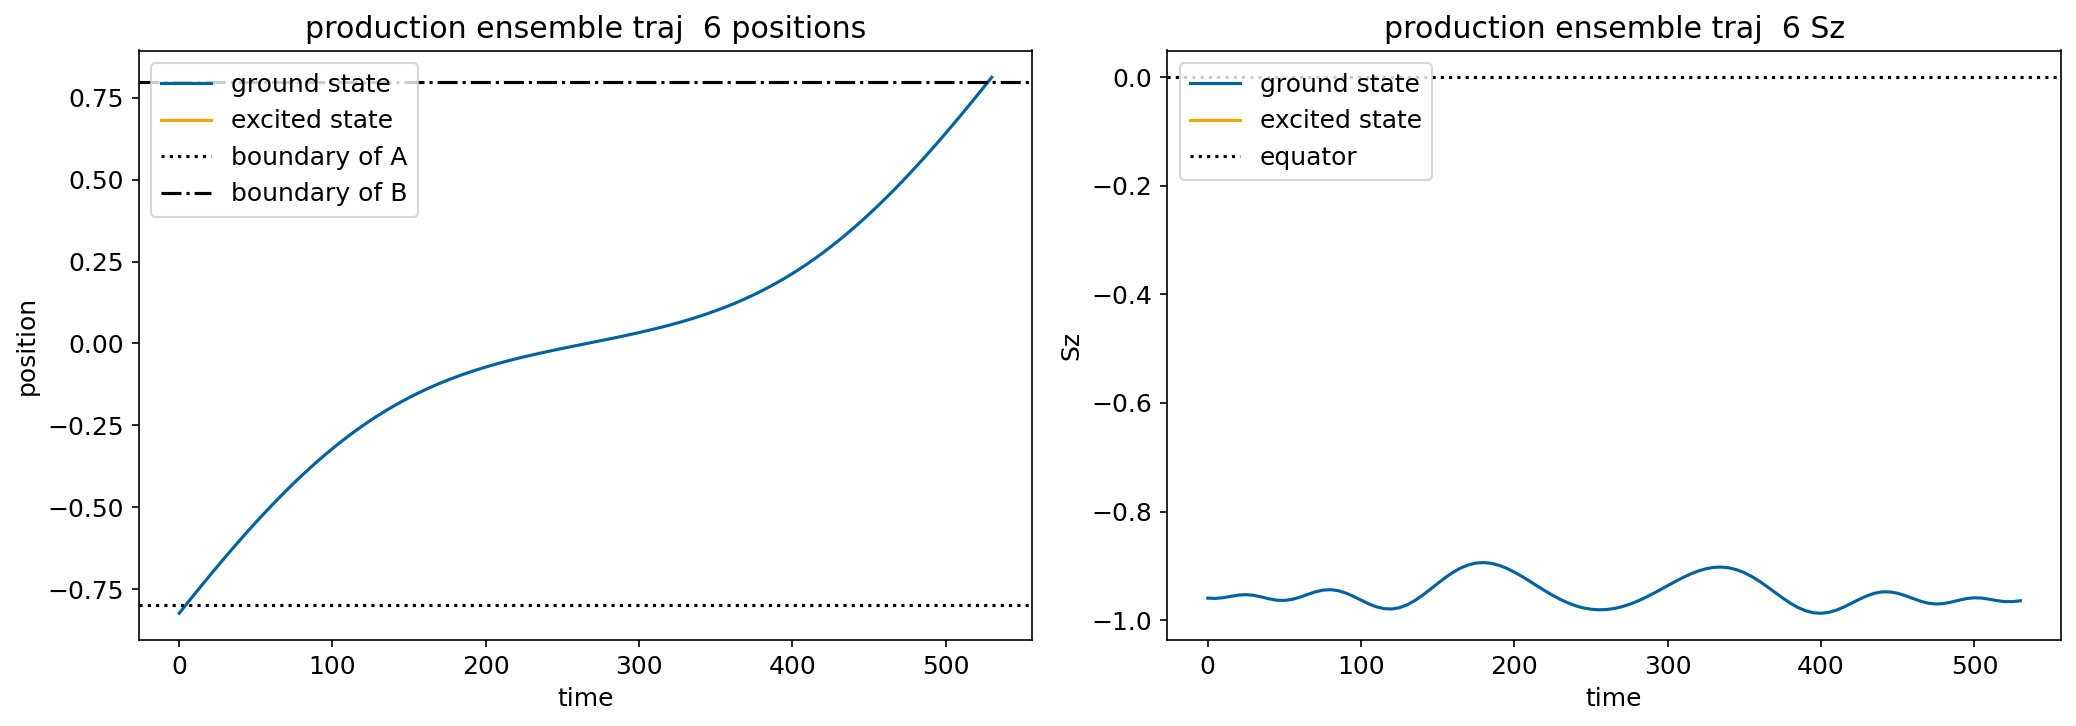

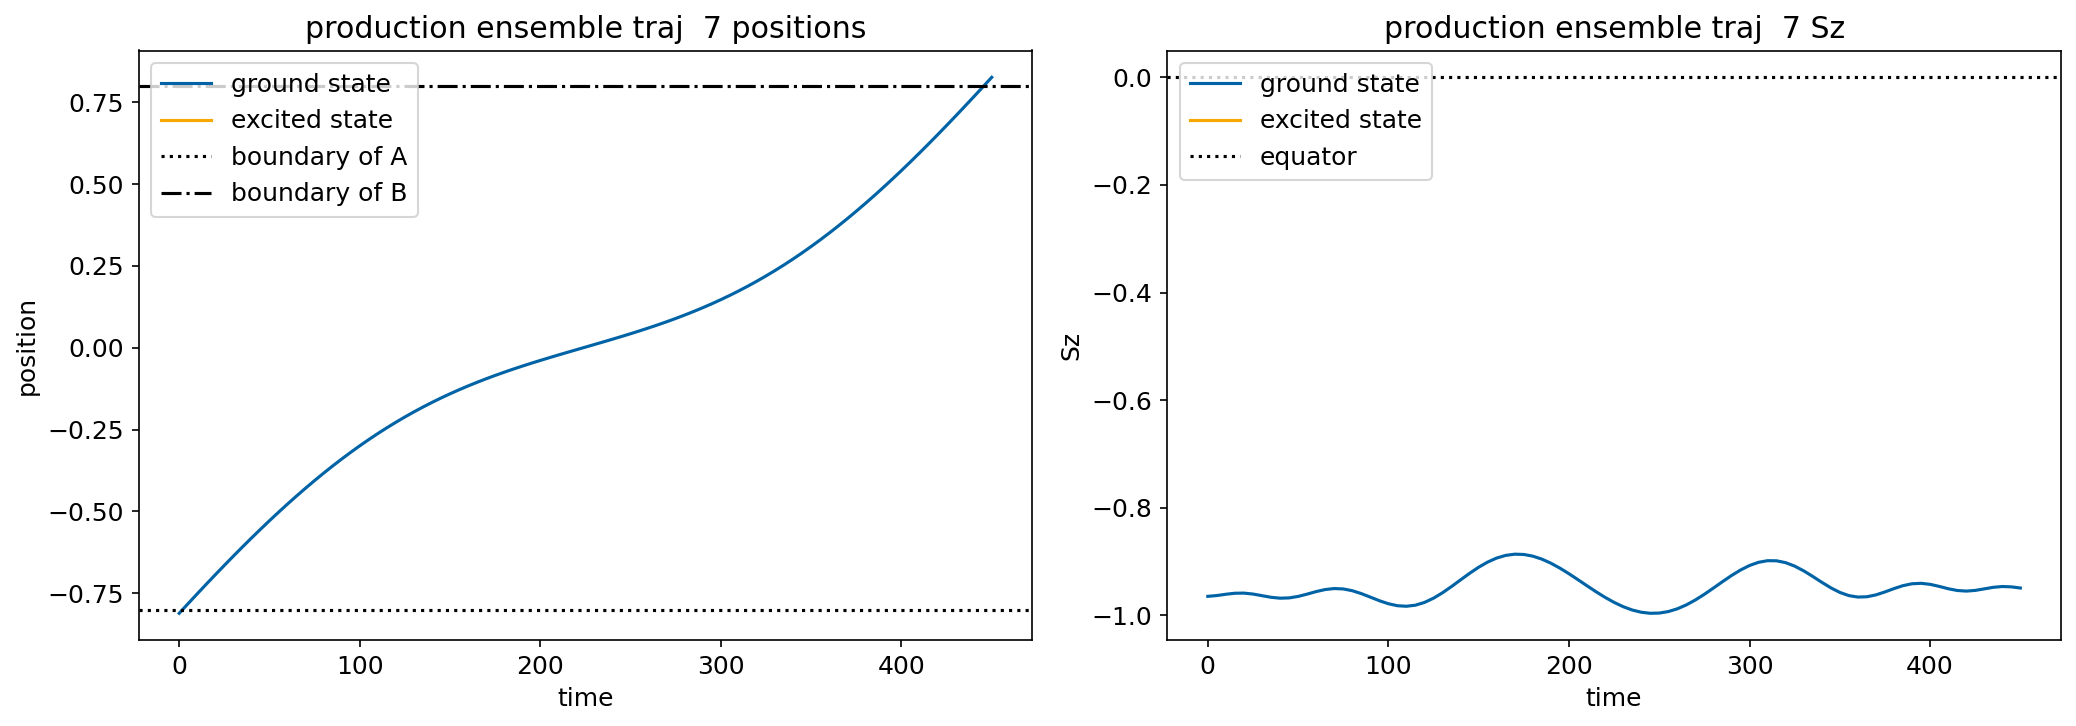

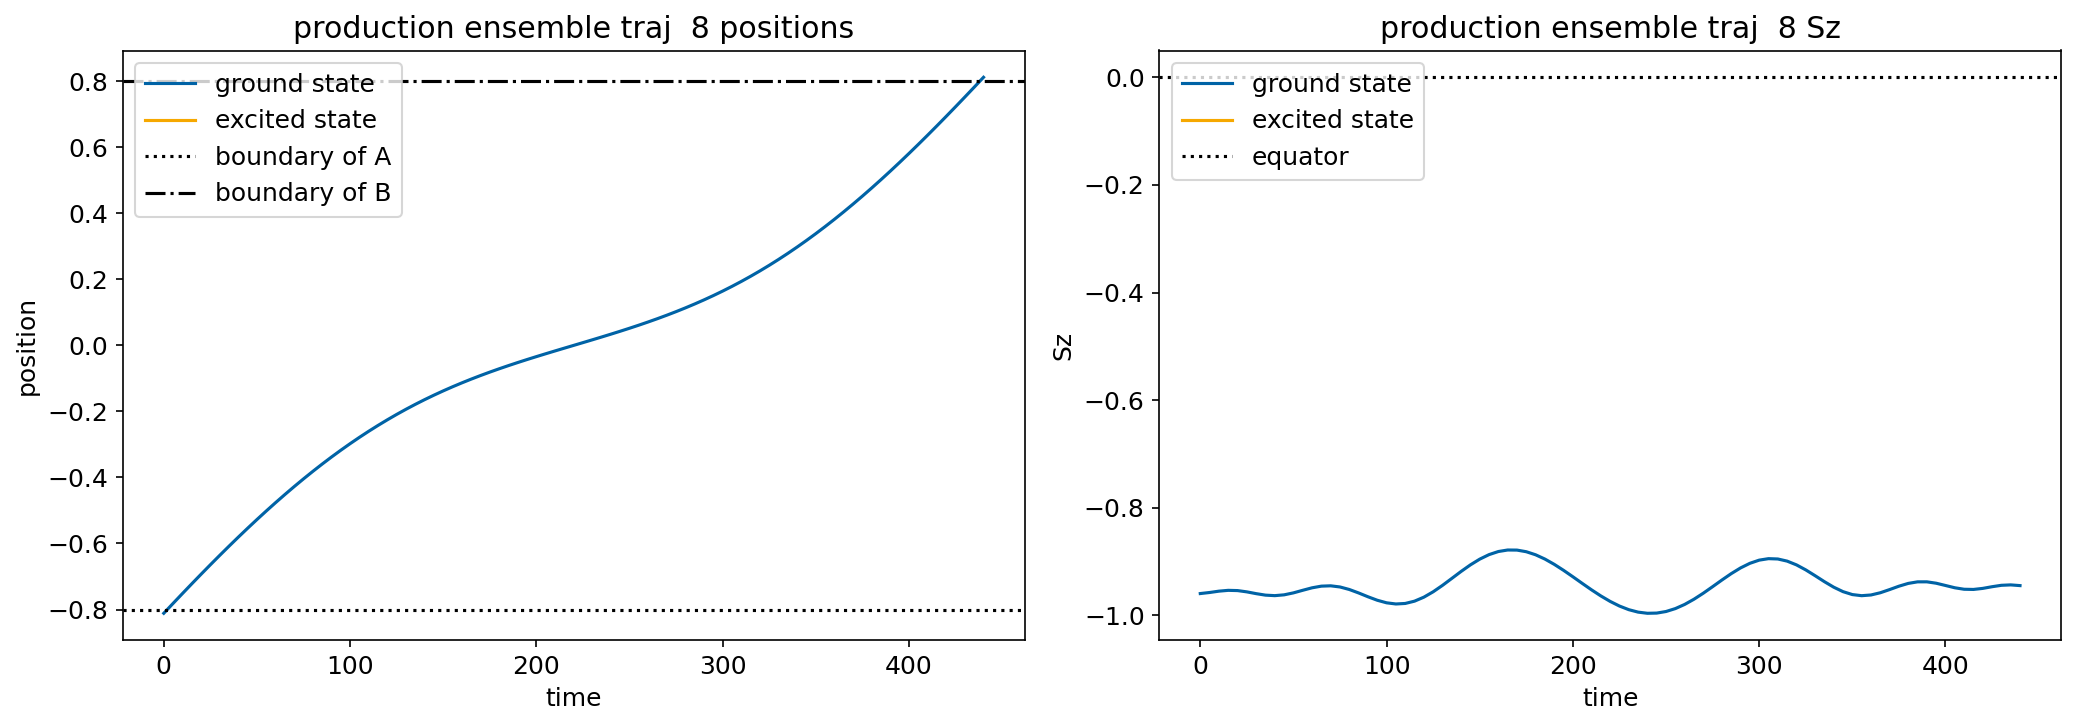

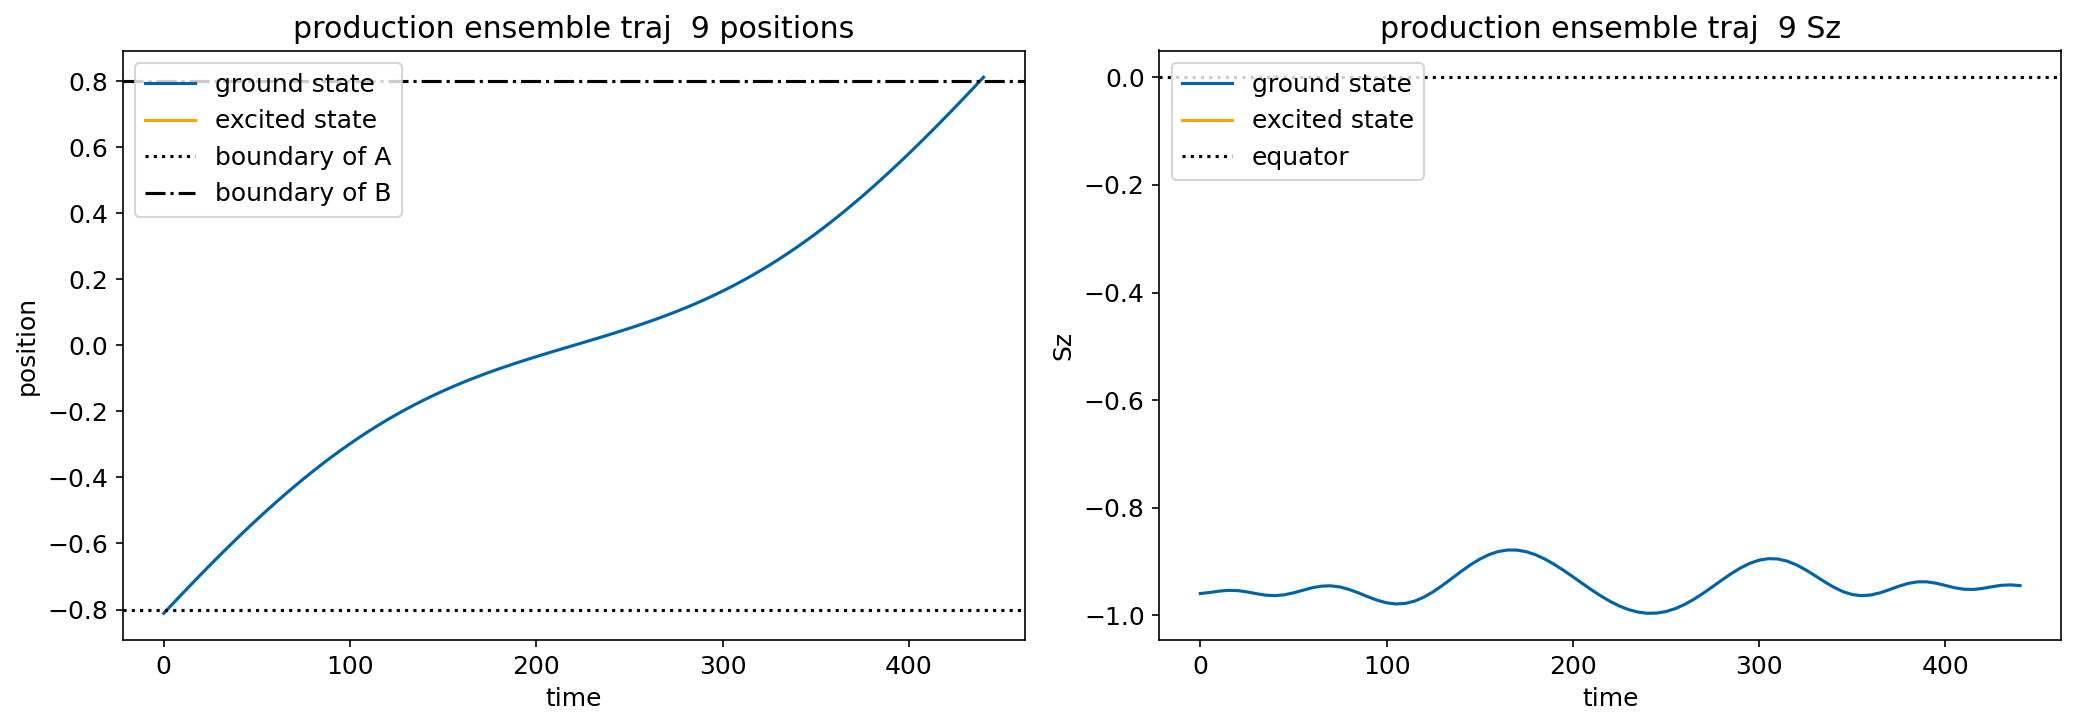

In [13]:
# Question again: Now what is this production_ensemble?

for k in range(10):
    traj = production_ensemble[k]
    # --- Positions ---
    oscillator_positions = np.array([traj[i].positions for i in range(len(traj))])
    active_states = np.array([traj[i].active_state for i in range(len(traj))])
    ground_state_positions = np.copy(oscillator_positions)
    ground_state_positions[active_states > 0] = np.nan
    excited_state_positions = np.copy(oscillator_positions)
    excited_state_positions[active_states != 1] = np.nan

    # --- Coefficients ---
    oscillator_coeffs = np.array([sz_from_coeff(traj[i].coefficients) for i in range(len(traj))])
    ground_state_coeffs = np.copy(oscillator_coeffs)
    ground_state_coeffs[active_states > 0] = np.nan
    excited_state_coeffs = np.copy(oscillator_coeffs)
    excited_state_coeffs[active_states != 1] = np.nan

    # --- Create subplots ---
    fig, axes = plt.subplots(ncols=2, figsize=(14, 5), dpi=150)

    # Left: Positions
    axes[0].plot(np.arange(len(traj)) * dt, ground_state_positions, color=colorstates[0], label="ground state")
    axes[0].plot(np.arange(len(traj)) * dt, excited_state_positions, color=colorstates[1], label="excited state")
    axes[0].axhline(y=bound_A, linestyle=":", color='black', label="boundary of A")
    axes[0].axhline(y=bound_B, linestyle="-.", color='black', label="boundary of B")
    axes[0].set_xlabel("time")
    axes[0].set_ylabel("position")
    axes[0].set_title(f"production ensemble traj{k:3d} positions")
    axes[0].legend(loc=2)

    # Right: Sz
    axes[1].plot(np.arange(len(traj)) * dt, ground_state_coeffs, color=colorstates[0], label="ground state")
    axes[1].plot(np.arange(len(traj)) * dt, excited_state_coeffs, color=colorstates[1], label="excited state")
    axes[1].axhline(y=0, linestyle=":", color='black', label="equator")
    axes[1].set_xlabel("time")
    axes[1].set_ylabel("Sz")
    axes[1].set_title(f"production ensemble traj{k:3d} Sz")
    axes[1].legend(loc=2)

    plt.tight_layout()
    plt.show()

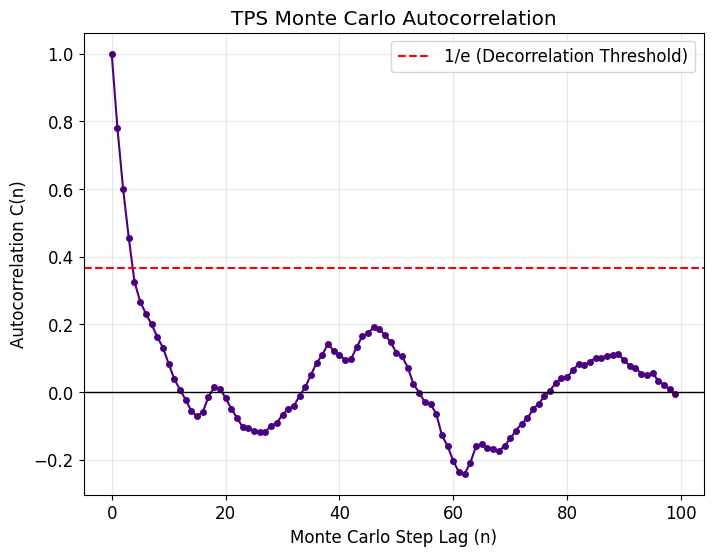

In [14]:
# COMPUTE AND PLOT AUTOCORRELATION FUNCTION OF TRANSITION TIMES

def compute_autocorrelation(data, max_lag=100):
    """Computes the normalized autocorrelation function of a 1D array."""
    mean = np.mean(data)
    var = np.var(data)
    data_centered = np.array(data) - mean
    
    N = len(data)
    autocorr = []
    
    for lag in range(max_lag):
        if lag == 0:
            autocorr.append(1.0)
        else:
            # Calculate covariance at the given lag
            cov = np.sum(data_centered[:-lag] * data_centered[lag:]) / (N - lag)
            autocorr.append(cov / var)
            
    return autocorr

# 1. Calculate the autocorrelation of your transit times
max_mc_lag = 100 # Look at correlation over 100 MC steps
C_n = compute_autocorrelation(transit_times, max_lag=max_mc_lag)

# 2. Plot the result
plt.figure(figsize=(8, 6))
plt.plot(range(max_mc_lag), C_n, marker='o', markersize=4, linestyle='-', color='indigo')
plt.axhline(0, color='black', linewidth=1)
plt.axhline(np.exp(-1), color='red', linestyle='dashed', label='1/e (Decorrelation Threshold)')

plt.title("TPS Monte Carlo Autocorrelation")
plt.xlabel("Monte Carlo Step Lag (n)")
plt.ylabel("Autocorrelation C(n)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()